# Detailed Exploratory Data Analysis (EDA) — Pearls AQI Predictor
**City**: Islamabad / Rawalpindi, Pakistan  
**Purpose**: This notebook performs a deep, multi-perspective exploratory data analysis on the hourly historical Air Quality Index (AQI) and meteorological dataset.

Our analysis spans:
1. **Data Integrity & Gaps**: Inspecting variables, data types, and missing values.
2. **Univariate AQI Distribution**: Assessing the distribution of AQI values.
3. **Temporal Seasonality & Cycles**:
   - **Diurnal (Hourly) Patterns**: Traffic rush hours and daily temperature/wind cycles.
   - **Weekly Patterns**: Weekdays vs. Weekends (industrial/commuter cycles).
   - **Seasonal (Monthly) Patterns**: Winter smog (crop residue burning, temperature inversions) vs. Monsoon wash-out.
4. **Pollutant Relationships**: Correlation between PM2.5, PM10, NO2, CO, O3, SO2.
5. **Meteorological Influences**: The impact of temperature, relative humidity, precipitation, wind speed/direction (wind vectors U & V) on air pollution.
6. **Time Series Lag Structure**: Examining autocorrelations and rolling statistical properties.
7. **Predictive Target Suitability**: Correlation of current features with 24h, 48h, and 72h ahead target AQIs.

## Setup and Data Load
We load dependencies, set seaborn styles for professional visualizations, and load our backfilled historical dataset.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set style for high-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

DATA_PATH = os.path.join('..', 'data', 'backfill_preview.csv')
if not os.path.exists(DATA_PATH):
    # fallback to data/ if run from notebooks/
    DATA_PATH = os.path.join('data', 'backfill_preview.csv')
    if not os.path.exists(DATA_PATH):
        DATA_PATH = '../data/backfill_preview.csv'

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4320, 42)


,timestamp,city,aqi,pm25,pm10,no2,co,o3,so2,temperature,...,aqi_lag_6h,aqi_lag_24h,aqi_change_1h,aqi_roll_3h,aqi_roll_6h,aqi_roll_24h,aqi_roll_std,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,2025-12-11 00:00:00+00:00,islamabad_rawalpindi,86.0,38.4,39.5,39.7,765.0,5.0,1.0,11.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.0,84.0,107.0
1,2025-12-11 01:00:00+00:00,islamabad_rawalpindi,86.0,33.2,34.3,45.2,1286.0,4.0,1.0,9.6,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,85.0,85.0,107.0
2,2025-12-11 02:00:00+00:00,islamabad_rawalpindi,86.0,37.3,38.6,52.5,1943.0,3.0,2.0,9.0,...,NaN,NaN,0.0,86.0,NaN,NaN,NaN,84.0,85.0,108.0
3,2025-12-11 03:00:00+00:00,islamabad_rawalpindi,86.0,42.5,44.1,55.2,2266.0,12.0,2.0,10.0,...,NaN,NaN,0.0,86.0,NaN,NaN,NaN,84.0,87.0,108.0
4,2025-12-11 04:00:00+00:00,islamabad_rawalpindi,86.0,38.8,40.2,49.1,1932.0,37.0,3.0,12.4,...,NaN,NaN,0.0,86.0,NaN,NaN,NaN,83.0,88.0,109.0


## 1. Data Integrity and Missing Values
Before diving into analysis, we must inspect the dataset's health. We will look at missing value rates, data types, and basic statistics.

In [2]:
print("--- Dataset Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
df.describe().T

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   timestamp       4320 non-null   datetime64[ns, UTC]
 1   city            4320 non-null   object             
 2   aqi             4320 non-null   float64            
 3   pm25            4320 non-null   float64            
 4   pm10            4320 non-null   float64            
 5   no2             4320 non-null   float64            
 6   co              4320 non-null   float64            
 7   o3              4320 non-null   float64            
 8   so2             4320 non-null   float64            
 9   temperature     4320 non-null   float64            
 10  humidity        4320 non-null   float64            
 11  wind_speed      4320 non-null   float64            
 12  wind_direction  4320 non-null   float64            
 13  pressure    

,count,mean,std,min,25%,50%,75%,max
aqi,4320.0,6.983403e+01,16.689460,28.000000,62.000000,68.00000,82.000000,118.000000
pm25,4320.0,3.793937e+01,24.575508,3.400000,20.200000,31.00000,48.300000,146.200000
pm10,4320.0,5.101227e+01,32.100203,4.800000,28.600000,41.80000,63.300000,338.100000
no2,4320.0,4.118762e+01,32.359850,0.000000,14.700000,32.30000,61.475000,150.900000
co,4320.0,9.864889e+02,755.291259,117.000000,435.000000,733.50000,1323.250000,5420.000000
o3,4320.0,7.004884e+01,53.521611,0.000000,24.000000,59.00000,111.000000,227.000000
so2,4320.0,2.564537e+01,41.262639,0.000000,4.000000,11.00000,27.000000,498.000000
temperature,4320.0,1.916201e+01,7.879218,2.800000,12.900000,18.20000,24.900000,40.300000
humidity,4320.0,5.633843e+01,20.154860,9.000000,41.000000,57.00000,71.000000,100.000000
wind_speed,4320.0,6.555370e+00,3.901724,0.000000,3.600000,5.90000,8.800000,32.700000


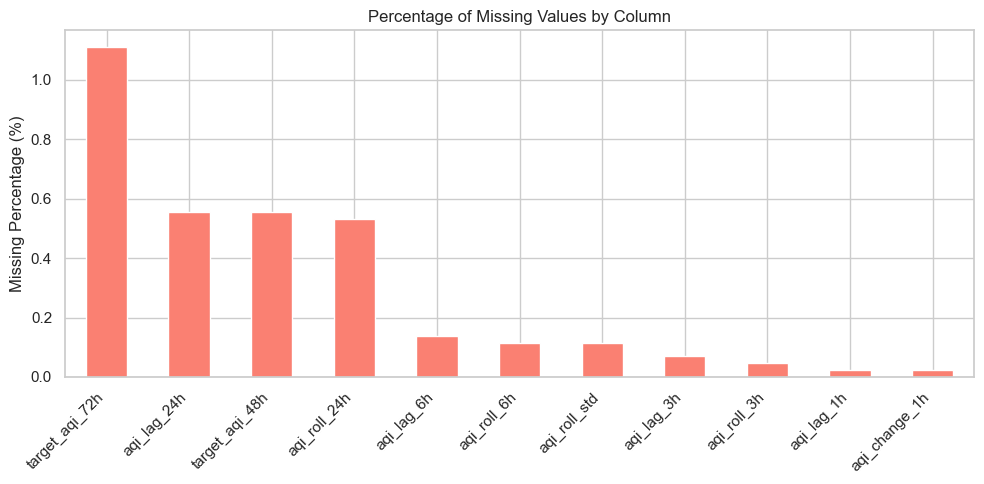

In [3]:
missing_series = df.isnull().mean() * 100
missing_series = missing_series[missing_series > 0]

if not missing_series.empty:
    plt.figure(figsize=(10, 5))
    missing_series.sort_values(ascending=False).plot(kind='bar', color='salmon')
    plt.title('Percentage of Missing Values by Column')
    plt.ylabel('Missing Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

## 2. Univariate AQI Distribution
Let's analyze the distribution of `aqi` values to see if it is skewed, its range, and how it aligns with health categories.

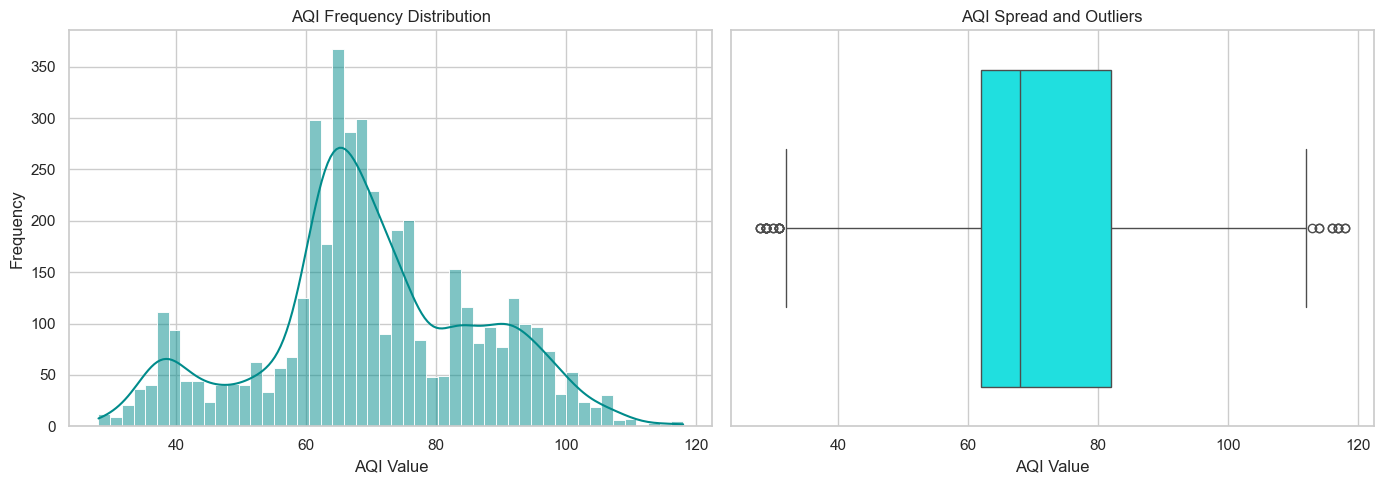

AQI Percentiles:
0.10     45.0
0.25     62.0
0.50     68.0
0.75     82.0
0.90     93.0
0.95     98.0
0.99    106.0
Name: aqi, dtype: float64


In [4]:
plt.figure(figsize=(14, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['aqi'], kde=True, bins=50, color='darkcyan')
plt.title('AQI Frequency Distribution')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')

# Boxplot to see outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['aqi'], color='cyan')
plt.title('AQI Spread and Outliers')
plt.xlabel('AQI Value')

plt.tight_layout()
plt.show()

# Quantiles
print("AQI Percentiles:")
print(df['aqi'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

## 3. Temporal Seasonality & Cycles
Air quality is heavily influenced by human cycles (traffic peak hours, workdays vs. weekends) and seasonal weather systems.

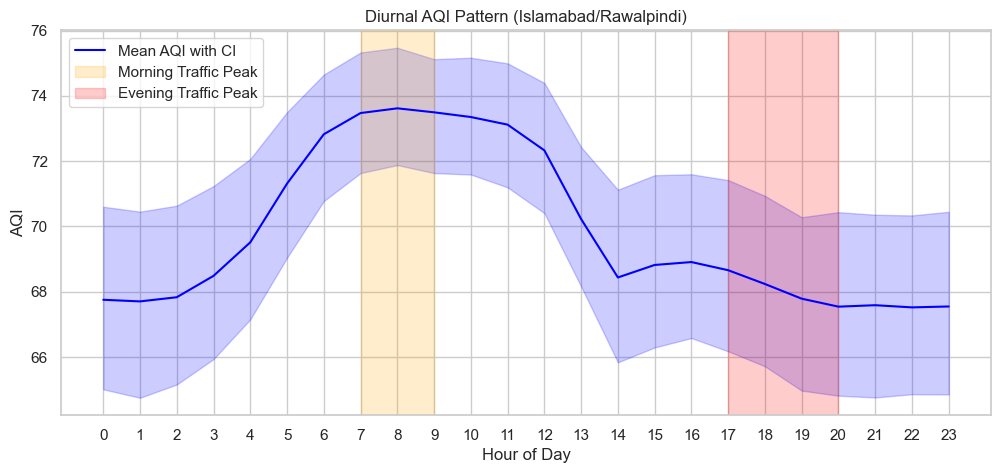

In [5]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour', y='aqi', errorbar='ci', color='blue', label='Mean AQI with CI')
plt.axvspan(7, 9, color='orange', alpha=0.2, label='Morning Traffic Peak')
plt.axvspan(17, 20, color='red', alpha=0.2, label='Evening Traffic Peak')
plt.title('Diurnal AQI Pattern (Islamabad/Rawalpindi)')
plt.xlabel('Hour of Day')
plt.ylabel('AQI')
plt.xticks(range(24))
plt.legend()
plt.show()

C:\Users\ABUBAKAR\AppData\Local\Temp\ipykernel_27936\3789412031.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_weekend_str', y='aqi', palette='Set2')


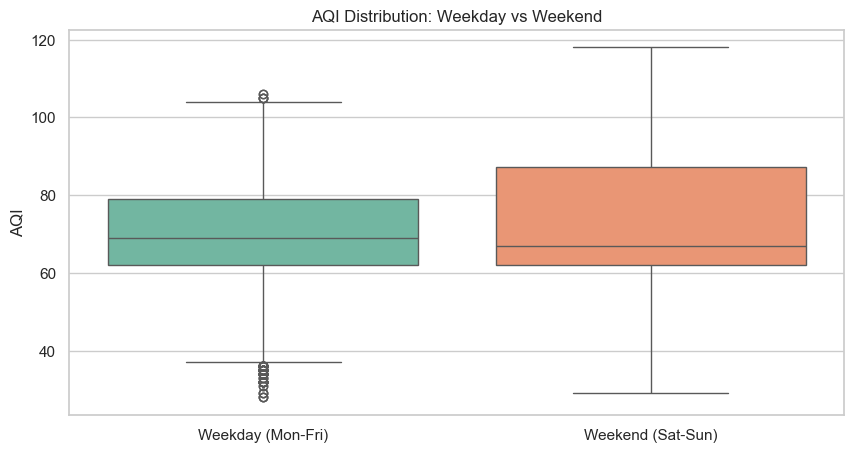

Mean AQI by Day Type:
is_weekend_str
Weekday (Mon-Fri)    69.173503
Weekend (Sat-Sun)    71.459936
Name: aqi, dtype: float64


In [6]:
df['is_weekend_str'] = df['day_of_week'].apply(lambda x: 'Weekend (Sat-Sun)' if x >= 5 else 'Weekday (Mon-Fri)')

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_weekend_str', y='aqi', palette='Set2')
plt.title('AQI Distribution: Weekday vs Weekend')
plt.ylabel('AQI')
plt.xlabel('')
plt.show()

print("Mean AQI by Day Type:")
print(df.groupby('is_weekend_str')['aqi'].mean())

C:\Users\ABUBAKAR\AppData\Local\Temp\ipykernel_27936\136840963.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month_name', y='aqi', order=month_names, palette='coolwarm')


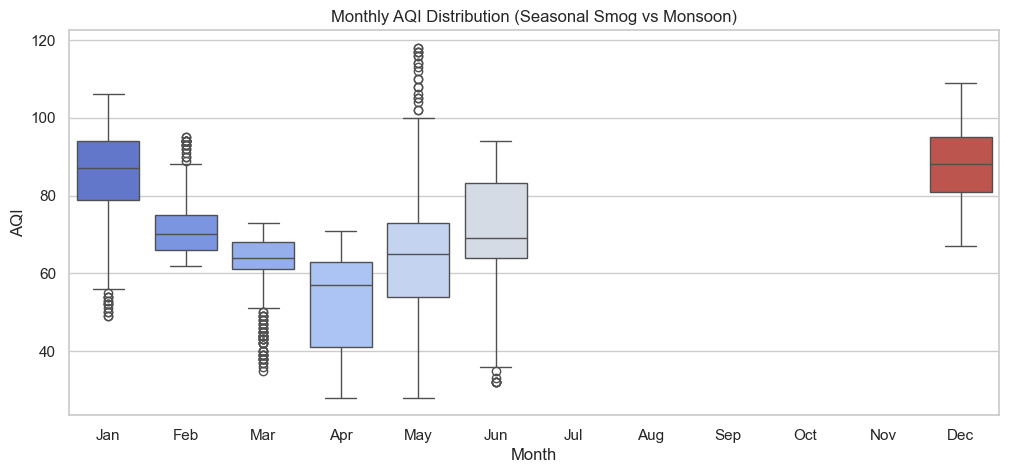

In [7]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Map month integers to names for plotting
df['month_name'] = df['month'].apply(lambda m: month_names[m-1])

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='month_name', y='aqi', order=month_names, palette='coolwarm')
plt.title('Monthly AQI Distribution (Seasonal Smog vs Monsoon)')
plt.ylabel('AQI')
plt.xlabel('Month')
plt.show()

## 4. Pollutant Interactions
Air quality indices are dictated by pollutant sub-indices. Let's see how they correlate with each other.

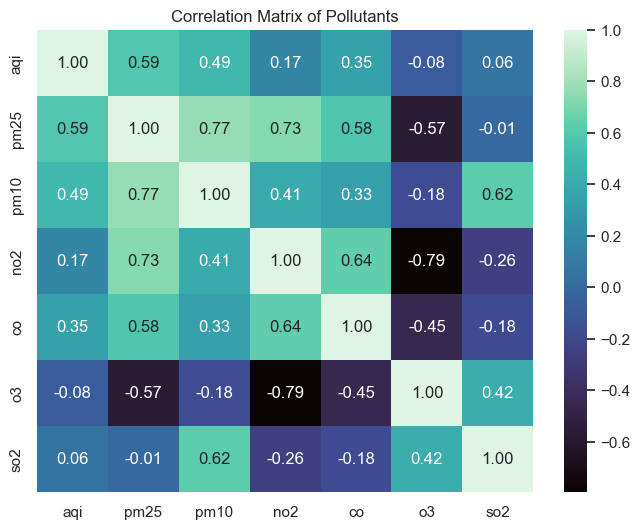

In [8]:
pollutants = ['aqi', 'pm25', 'pm10', 'no2', 'co', 'o3', 'so2']
available_polls = [p for p in pollutants if p in df.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df[available_polls].corr(), annot=True, cmap='mako', fmt='.2f')
plt.title('Correlation Matrix of Pollutants')
plt.show()

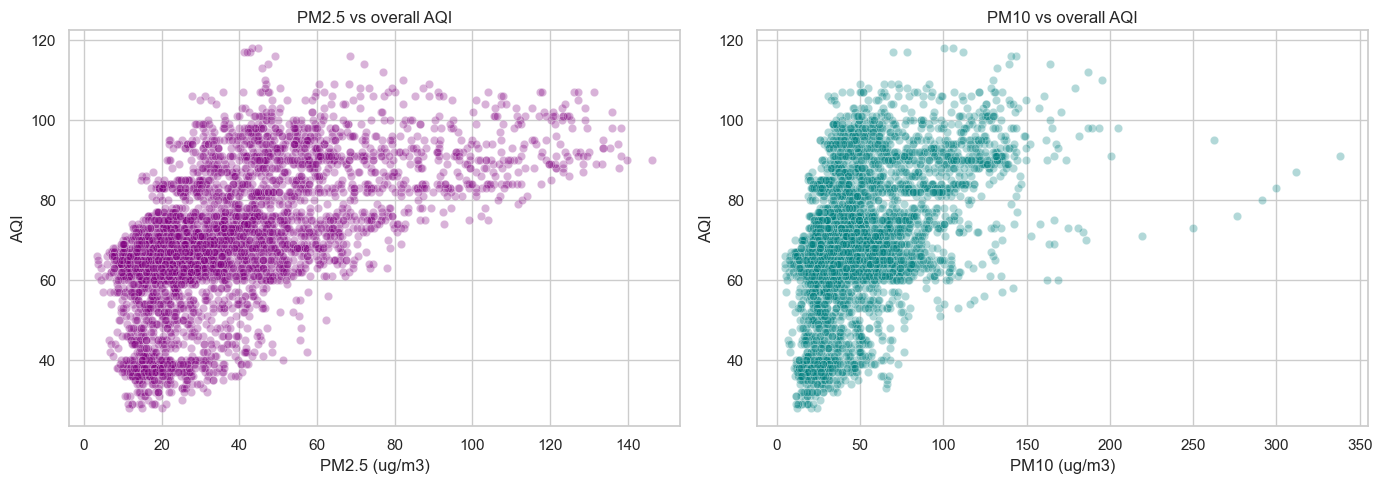

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='pm25', y='aqi', alpha=0.3, color='purple')
plt.title('PM2.5 vs overall AQI')
plt.xlabel('PM2.5 (ug/m3)')
plt.ylabel('AQI')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='pm10', y='aqi', alpha=0.3, color='teal')
plt.title('PM10 vs overall AQI')
plt.xlabel('PM10 (ug/m3)')
plt.ylabel('AQI')

plt.tight_layout()
plt.show()

## 5. Meteorological Influence on Air Quality
Weather determines whether pollutants stay trapped near the ground (stable conditions, low wind, high pressure) or disperse.

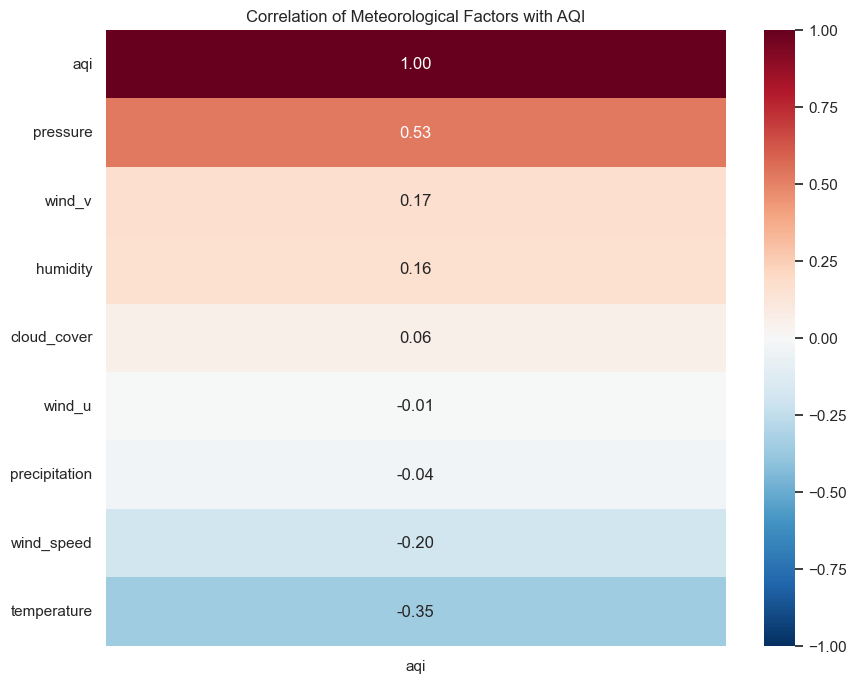

In [10]:
weather_cols = ['aqi', 'temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation', 'cloud_cover', 'wind_u', 'wind_v']
available_weathers = [c for c in weather_cols if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[available_weathers].corr()[['aqi']].sort_values(by='aqi', ascending=False), 
annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation of Meteorological Factors with AQI')
plt.show()

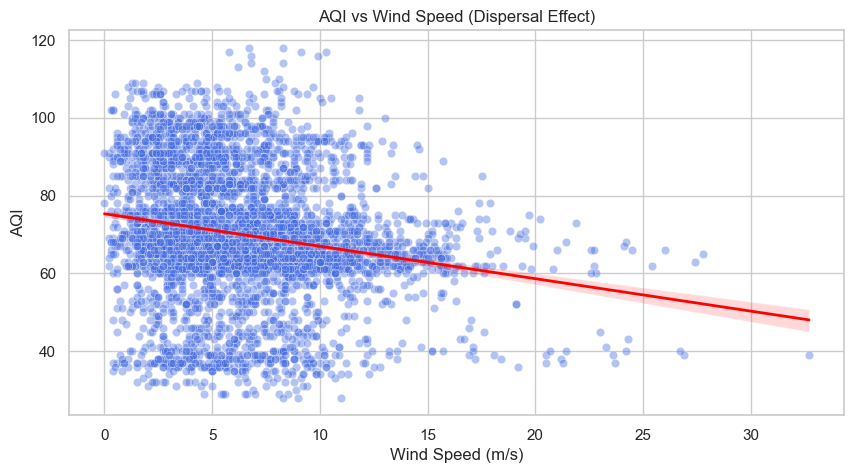

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='wind_speed', y='aqi', alpha=0.4, color='royalblue')
sns.regplot(data=df, x='wind_speed', y='aqi', scatter=False, color='red', line_kws={"linewidth": 2})
plt.title('AQI vs Wind Speed (Dispersal Effect)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('AQI')
plt.show()

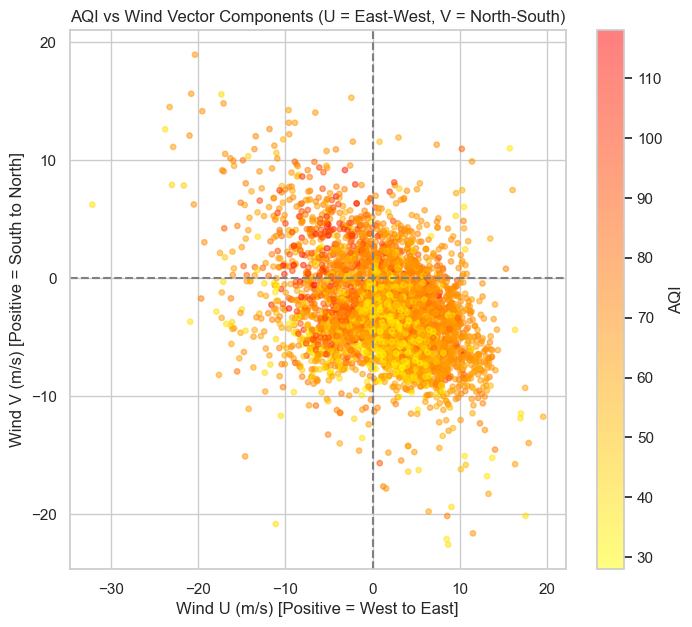

In [12]:
plt.figure(figsize=(8, 7))
sc = plt.scatter(df['wind_u'], df['wind_v'], c=df['aqi'], cmap='autumn_r', alpha=0.5, s=15)
plt.colorbar(sc, label='AQI')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title('AQI vs Wind Vector Components (U = East-West, V = North-South)')
plt.xlabel('Wind U (m/s) [Positive = West to East]')
plt.ylabel('Wind V (m/s) [Positive = South to North]')
plt.show()

Mean AQI during dry hours: 69.99
Mean AQI during rainy hours: 68.05


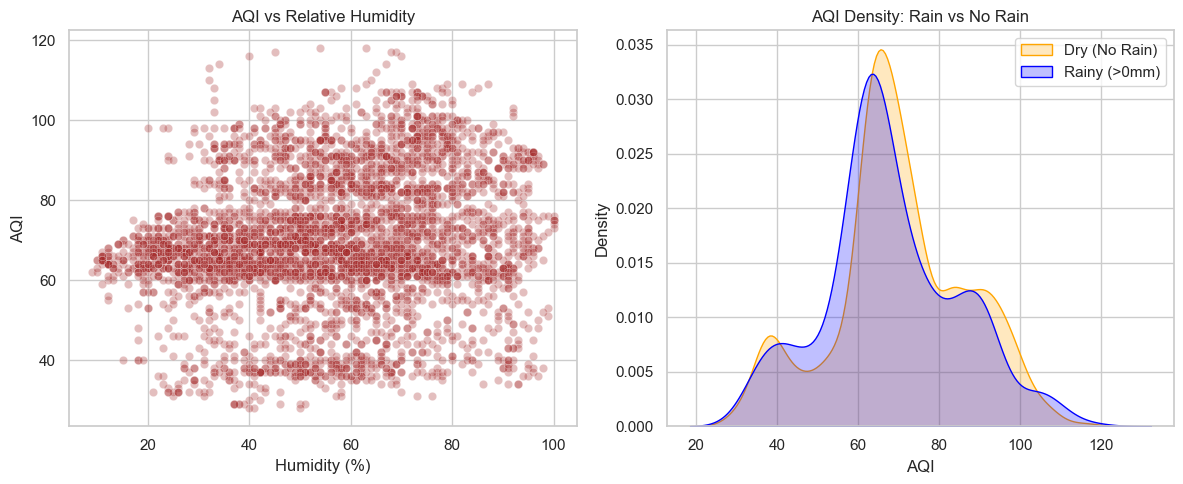

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='humidity', y='aqi', alpha=0.3, color='brown')
plt.title('AQI vs Relative Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('AQI')

plt.subplot(1, 2, 2)
rainy_days = df[df['precipitation'] > 0]
non_rainy_days = df[df['precipitation'] == 0]
print(f"Mean AQI during dry hours: {non_rainy_days['aqi'].mean():.2f}")
print(f"Mean AQI during rainy hours: {rainy_days['aqi'].mean():.2f}")

sns.kdeplot(non_rainy_days['aqi'], fill=True, label='Dry (No Rain)', color='orange')
if len(rainy_days) > 10:
    sns.kdeplot(rainy_days['aqi'], fill=True, label='Rainy (>0mm)', color='blue')
plt.title('AQI Density: Rain vs No Rain')
plt.xlabel('AQI')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Time-Series Analysis & Lag Structures
Air quality is highly autoregressive. Let's explore the autocorrelation (ACF) and PACF structure.

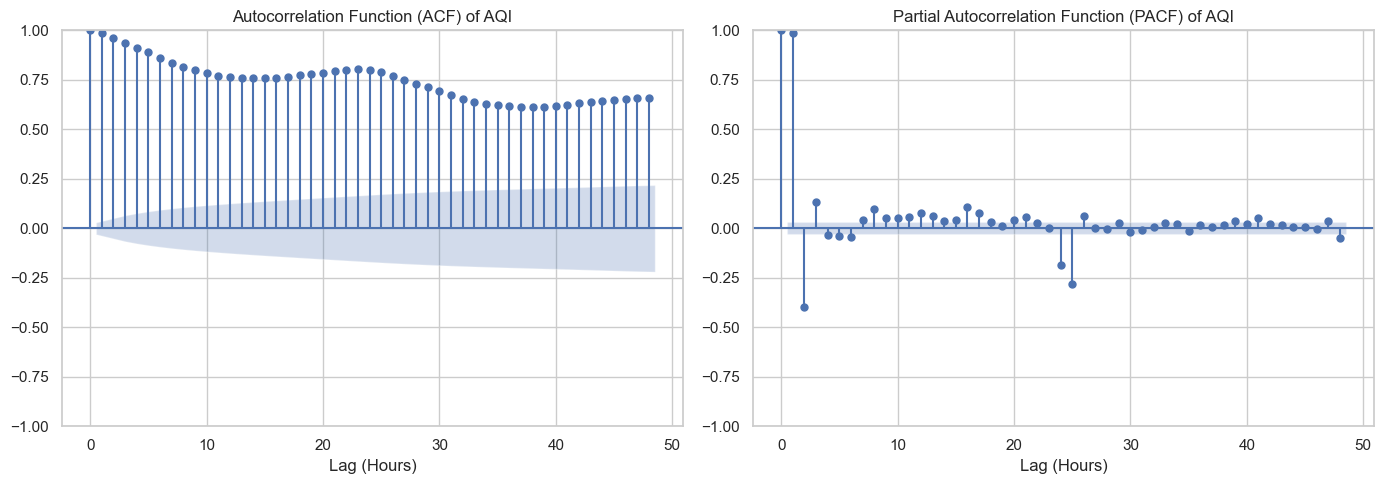

In [14]:
aqi_ts = df['aqi'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(aqi_ts, lags=48, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) of AQI')
ax[0].set_xlabel('Lag (Hours)')

plot_pacf(aqi_ts, lags=48, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) of AQI')
ax[1].set_xlabel('Lag (Hours)')

plt.tight_layout()
plt.show()

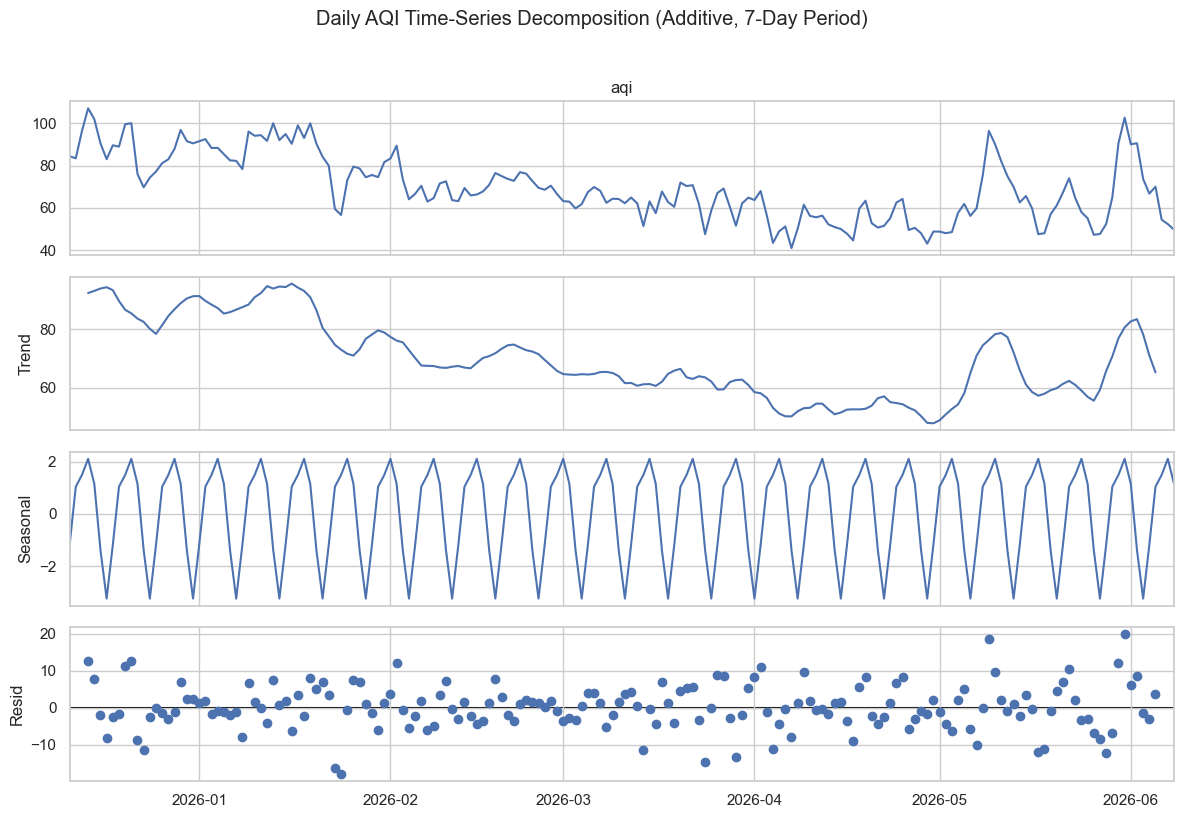

In [15]:
# Decomposition of daily resampled time series
daily_aqi = df.set_index('timestamp')['aqi'].resample('D').mean().interpolate(method='time')
decomposition = seasonal_decompose(daily_aqi, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Daily AQI Time-Series Decomposition (Additive, 7-Day Period)', y=1.02)
plt.tight_layout()
plt.show()

## 7. Predictive Target Suitability
Let's see how our lag/rolling variables correlate with target columns: `target_aqi_24h`, `target_aqi_48h`, and `target_aqi_72h`.

--- Top 10 Correlations with 24h Target ---
                target_aqi_24h
target_aqi_24h        1.000000
aqi                   0.810541
target_aqi_48h        0.809794
aqi_roll_3h           0.800868
aqi_lag_1h            0.797330
aqi_roll_6h           0.781746
aqi_lag_3h            0.758434
aqi_roll_24h          0.728467
aqi_lag_6h            0.698806
aqi_lag_24h           0.672919
target_aqi_72h        0.671789

--- Top 5 Negative Correlations with 24h Target ---
              target_aqi_24h
hour_cos           -0.094385
wind_speed         -0.160346
aqi_roll_std       -0.291846
temperature        -0.345681
month_sin          -0.456030


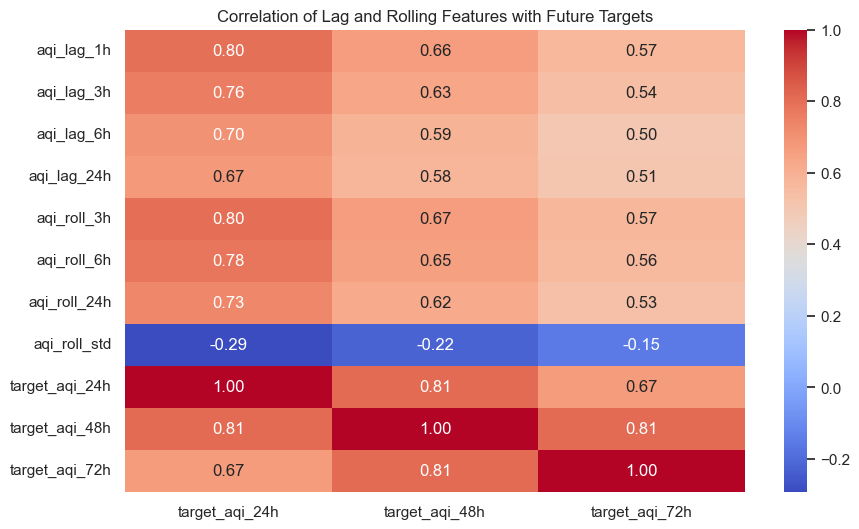

In [16]:
target_cols = ['target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']
available_targets = [t for t in target_cols if t in df.columns]

if available_targets:
    corr_24h = df.corr(numeric_only=True)[['target_aqi_24h']].sort_values(by='target_aqi_24h', ascending=False)
    print("--- Top 10 Correlations with 24h Target ---")
    print(corr_24h.head(11))
    
    print("\n--- Top 5 Negative Correlations with 24h Target ---")
    print(corr_24h.tail(5))
    
    lag_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
    if lag_cols:
        plt.figure(figsize=(10, 6))
        sns.heatmap(df[lag_cols + available_targets].corr()[available_targets], annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation of Lag and Rolling Features with Future Targets')
        plt.show()
else:
    print("Target columns not present. Running the feature pipeline/backfill is required to compute targets.")